## Let find the ground state (here blue noise) of a particule system

We will perform standard gradient descent with jax

In [58]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax, vmap
from functools import partial

from squarenet import SquareNet


# =========================
# CONFIG
# =========================

I, J = 300, 300
N = I * J
D = 2

sigma2 = (0.5/I)**2
lr = 0.03


# =========================
# DATA
# =========================

pts = np.random.rand(N, D)


# =========================
# INITIAL STRUCTURE (SquareNet)
# =========================

sqnet = SquareNet(IJ_=(I, J))
sqnet.fit(pts)

points = sqnet.map(pts).reshape(I, J, D)


# =========================
# GRID SHIFTS
# =========================

wr = 10
shifts = jnp.array([
    (di, dj)
    for di in range(-wr, wr+1)
    for dj in range(-wr, wr+1)
    if (di, dj) != (0, 0)
])


# =========================
# INTERACTION (stable form)
# =========================

def interaction(x, y, sigma2):
    delta = (y - x + 0.5) % 1.0 - 0.5
    dist2 = jnp.sum(delta ** 2, axis=-1, keepdims=True)

    w = jnp.exp(-dist2 / sigma2)
    return (2.0/sigma2)*(delta * w) 

def compute_grad(x, sigma2):

    def one_shift(s):
        di, dj = s
        y = jnp.roll(x, (di, dj), axis=(0, 1))
        return interaction(x, y, sigma2)

    grads = vmap(one_shift)(shifts)

    grad = jnp.mean(grads, axis=0)
    
    return grad


# =========================
# ground_stateATION STEP
# =========================

@partial(jax.jit, static_argnames=("max_iter",))
def ground_state(x, max_iter=10, lr=0.1, sigma2=1e-2):

    def step(_, x):
        g = compute_grad(x, sigma2)
        x = x - lr * g

        return x%1

    return lax.fori_loop(0, max_iter, step, x)

# =========================
# INITIAL ground_stateATION
# =========================

points = ground_state(points, max_iter=10, lr=lr, sigma2=sigma2)


# =========================
# SCHEDULE
# =========================

lr_list = np.logspace(-2, -4, 10)


# =========================
# MAIN LOOP
# =========================

for i, lr in enumerate(lr_list):

    print(f"Step {i} | lr={lr:.3f}")

    # 1) structure update (occasionnel)
    flat = points.reshape(-1, D)

    sqnet = SquareNet(IJ_=(I, J), warnings_ = False)
    sqnet.fit(flat)

    points = sqnet.map(flat).reshape(I, J, D)

    # 2) physical ground_stateation
    points = ground_state(points, max_iter=10, lr=lr, sigma2=sigma2)

succesfully sorted at iteration 11
Step 0 | lr=0.010
succesfully sorted at iteration 9
Step 1 | lr=0.006
succesfully sorted at iteration 10
Step 2 | lr=0.004
succesfully sorted at iteration 10
Step 3 | lr=0.002
succesfully sorted at iteration 9
Step 4 | lr=0.001
succesfully sorted at iteration 8
Step 5 | lr=0.001
succesfully sorted at iteration 7
Step 6 | lr=0.000
succesfully sorted at iteration 6
Step 7 | lr=0.000
succesfully sorted at iteration 7
Step 8 | lr=0.000
succesfully sorted at iteration 6
Step 9 | lr=0.000
succesfully sorted at iteration 7


## Let look at the beautiful blue noise we just generated

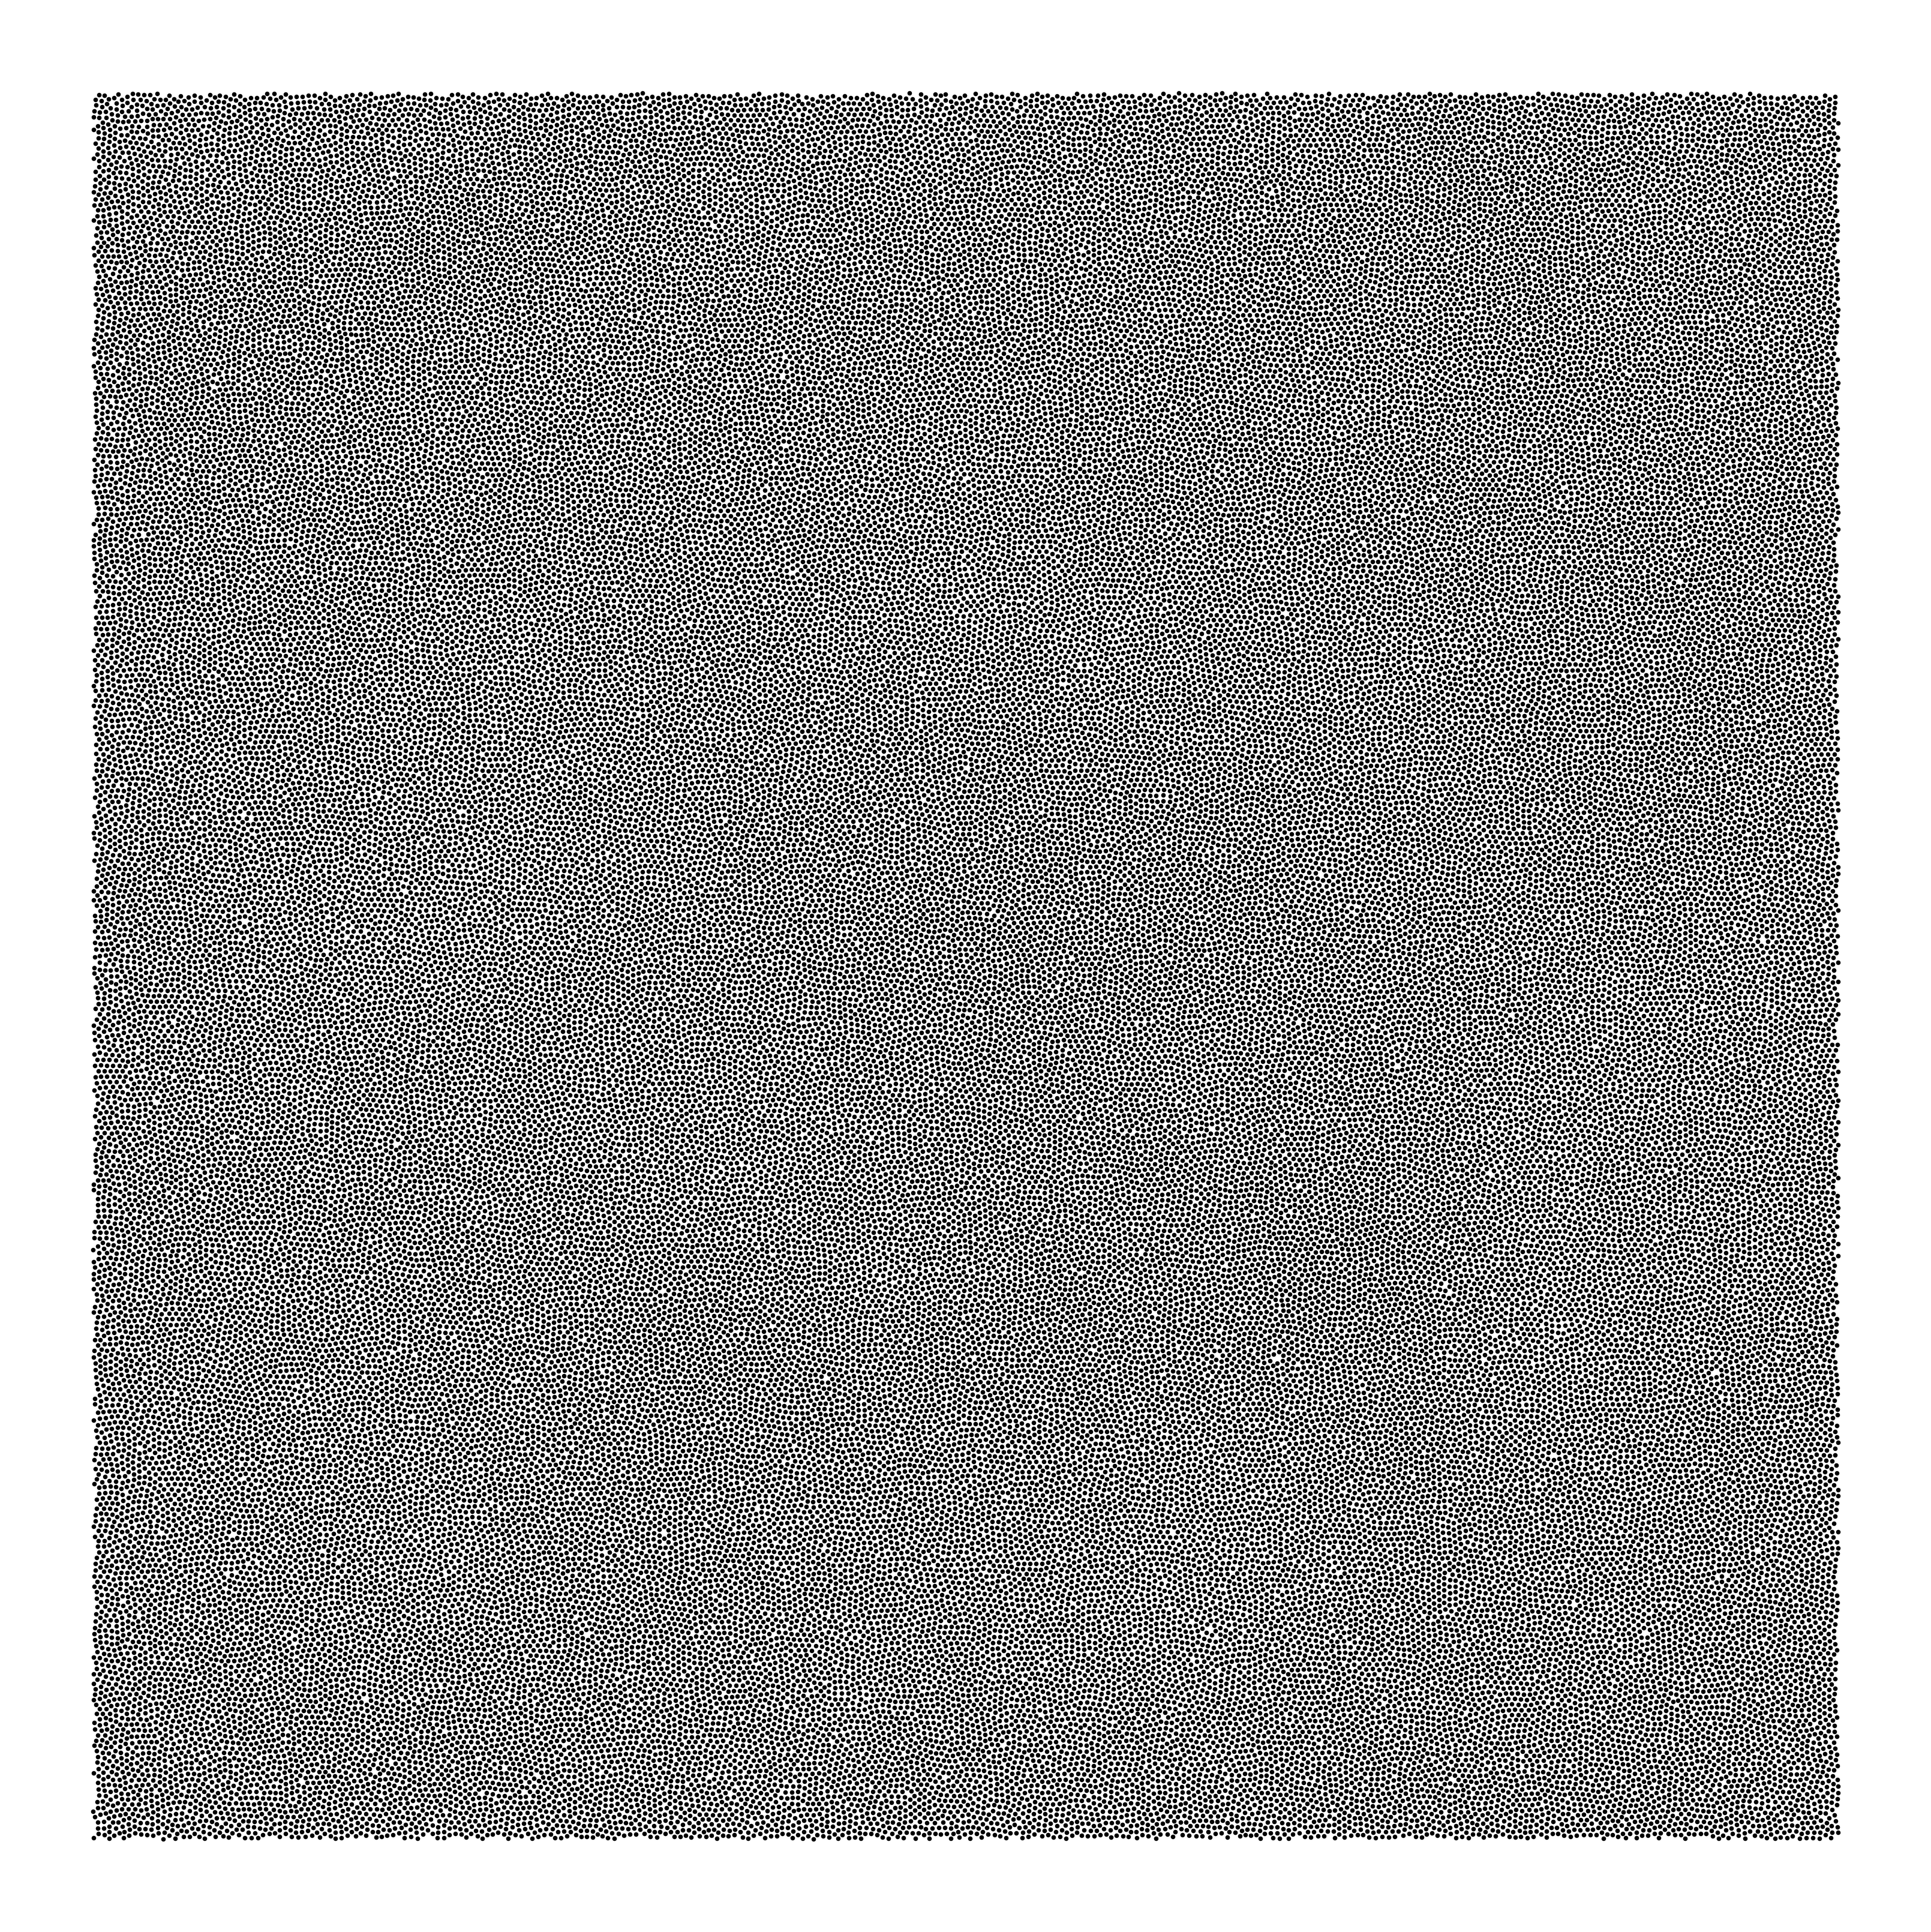

In [61]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(32, 32))
ax = fig.add_axes([0, 0, 1, 1])  
ax.set_aspect("equal")
ax.set_axis_off()

ax.scatter(points[..., 0].ravel(),
            points[..., 1].ravel(),
            s=20, color="black")
plt.savefig(
    "another_blue_noise.png",
    dpi=300,
    bbox_inches=None,   # IMPORTANT
    pad_inches=0
)
plt.show()

Note: Because of the periodic boundary conditions in the energy function, we can tile our point set as many times as desired without disrupting the visual continuity (see the periodized plot).

Or at least, the human eye cannot detect the trickery…

In [ ]:
#will you detect the periodification ?
periodized = (points + 0.5)%1 - 0.5

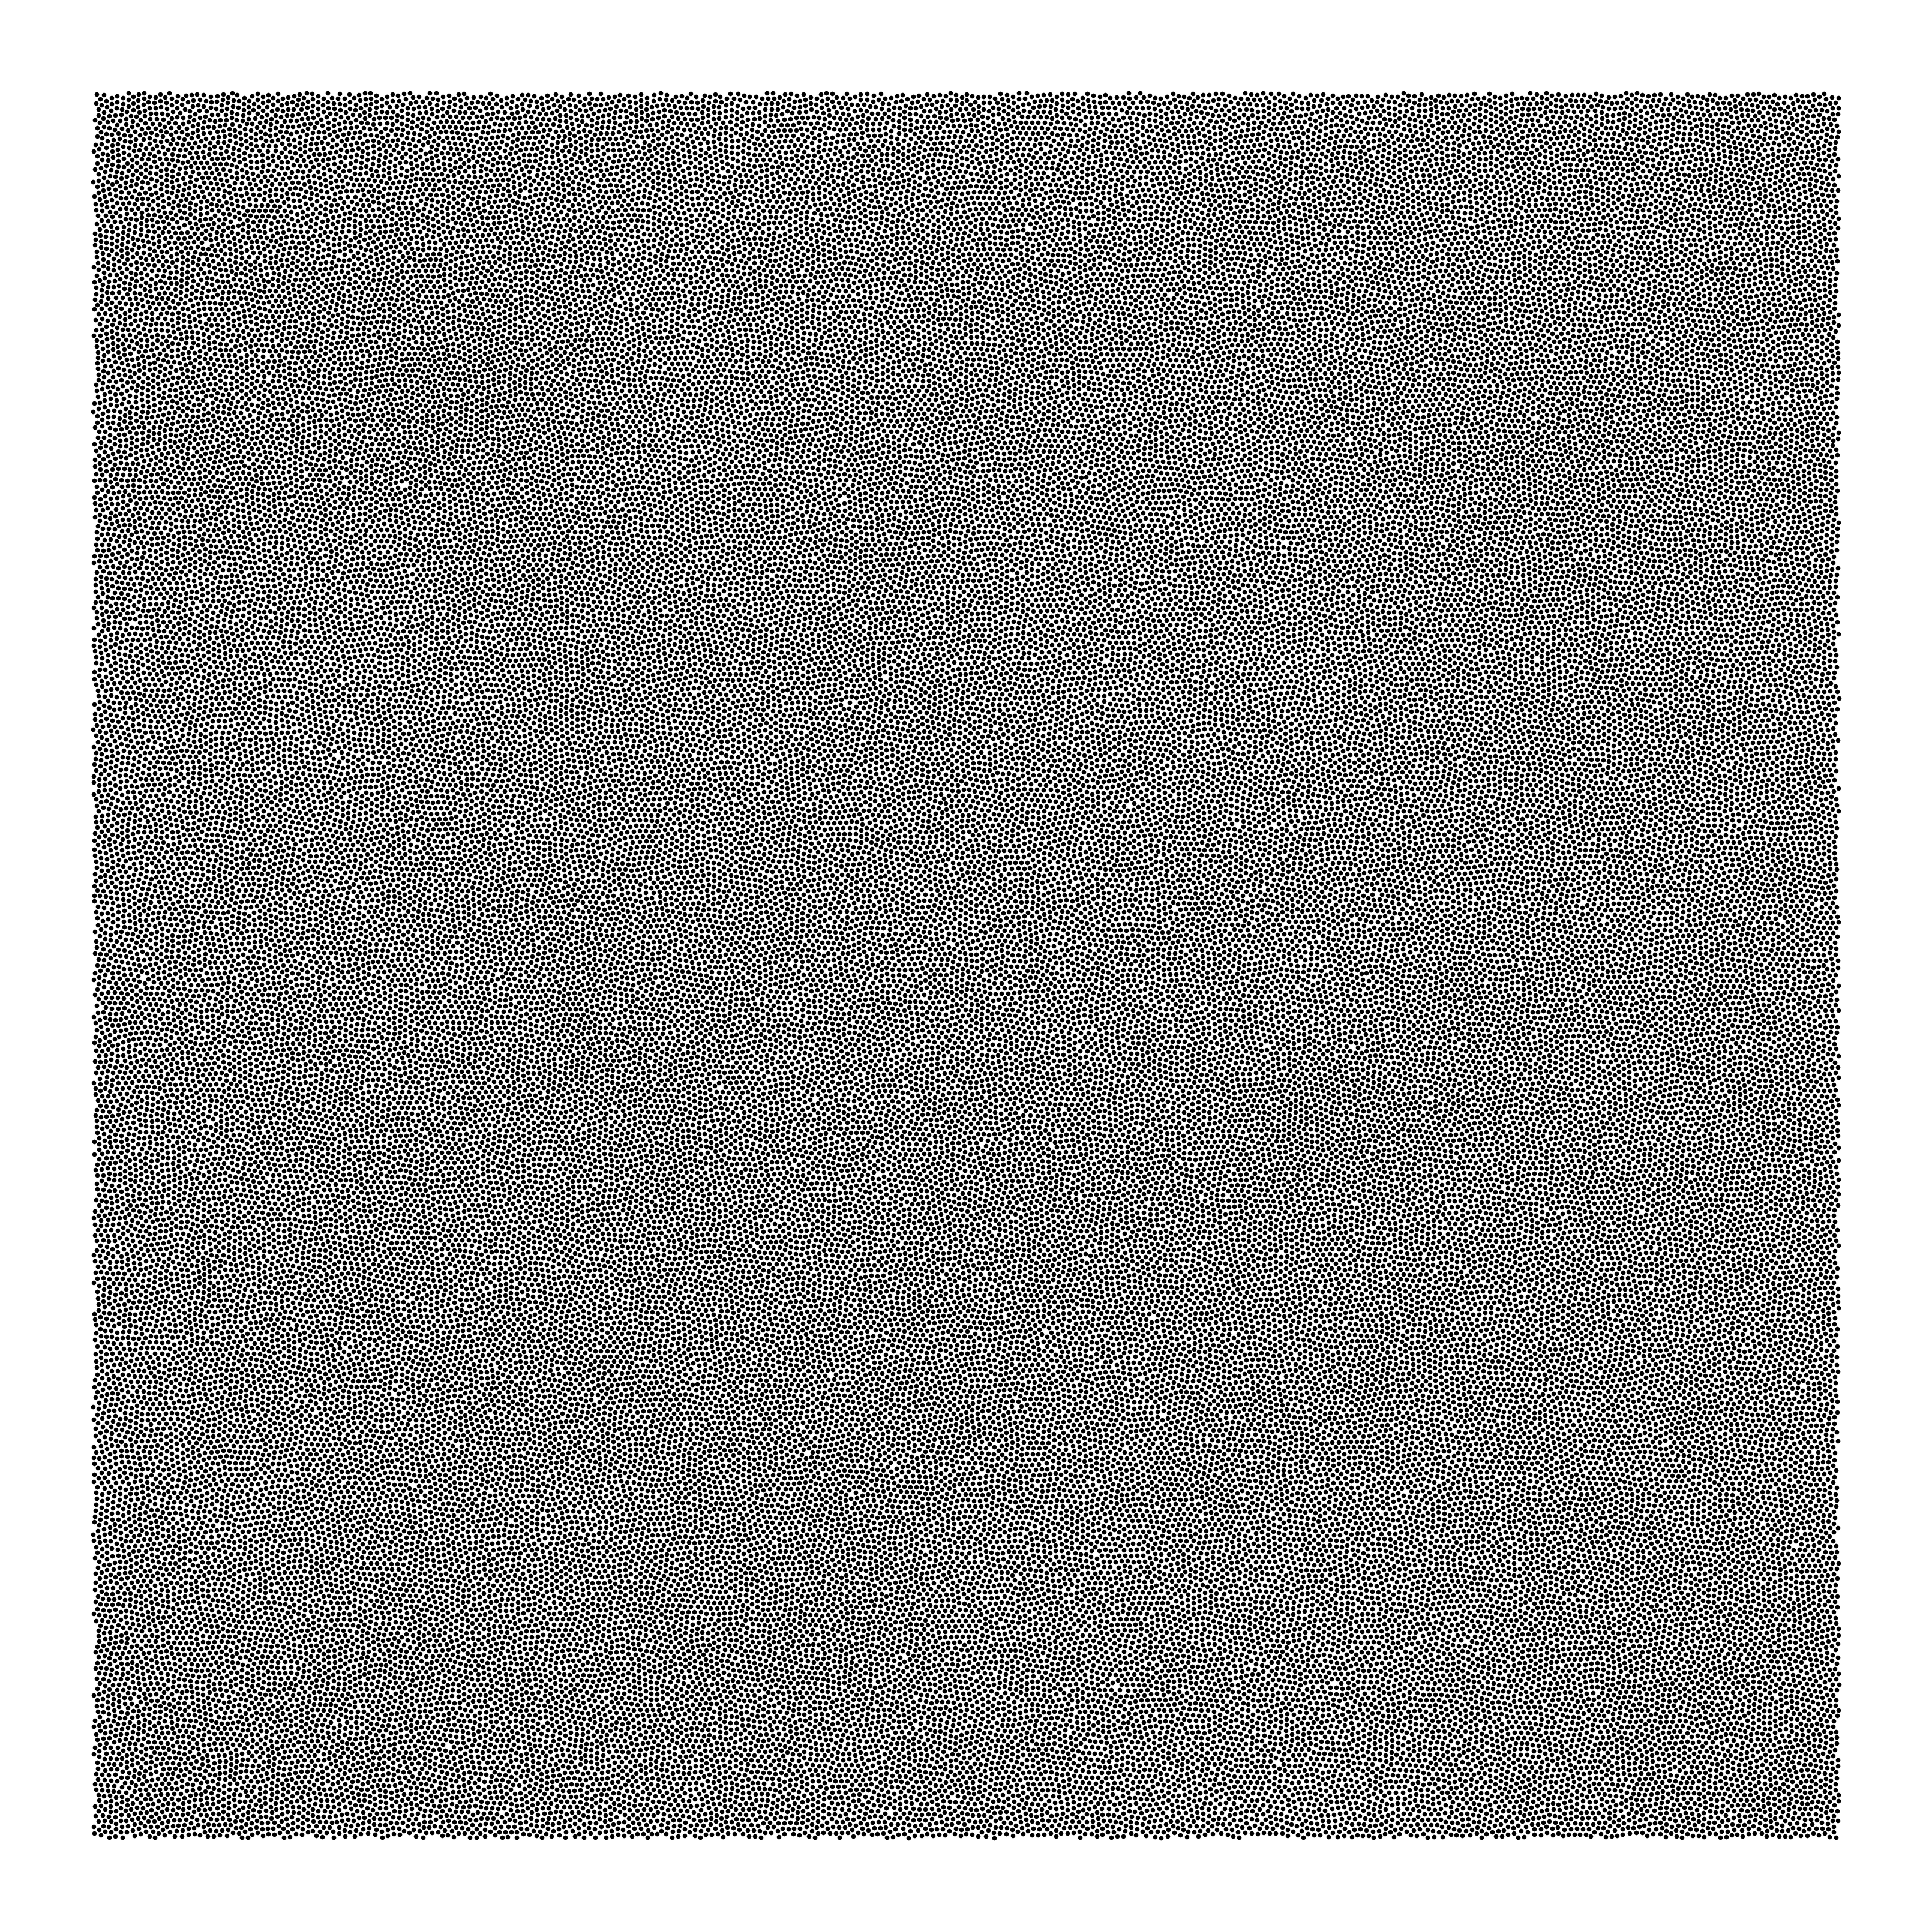

In [ ]:
fig = plt.figure(figsize=(32, 32))
ax = fig.add_axes([0, 0, 1, 1])  
ax.set_aspect("equal")
ax.set_axis_off()

ax.scatter(periodized[..., 0].ravel(),
            periodized[..., 1].ravel(),
            s=20, color="black")

plt.show()